# ViT neural net with pytorch (and pytorch lightning ⚡)


* We will be training a VIT on a subset tiny image dataset


In [171]:
# import standard PyTorch modules
import pytorch_lightning as pl
import pdb
import lightning
import torchmetrics
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

# import torchvision module to handle image manipulation
import torchvision
import torchvision.transforms as transforms

In [172]:
from lightning.pytorch import seed_everything

seed_everything(2026, workers=True)

Seed set to 2026


2026

In [173]:
# Check PyTorch versions
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu130
0.26.0+cu130


## Load the data and visualize it

In [174]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# ImageFolder STANDARD
train_dataset = datasets.ImageFolder(
    root="./datasets_split/train",
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root="./datasets_split/val",
    transform=val_transform
)



In [175]:
num_workers = 12

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=num_workers, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=24, shuffle=False, num_workers=num_workers, persistent_workers=True, pin_memory=True)


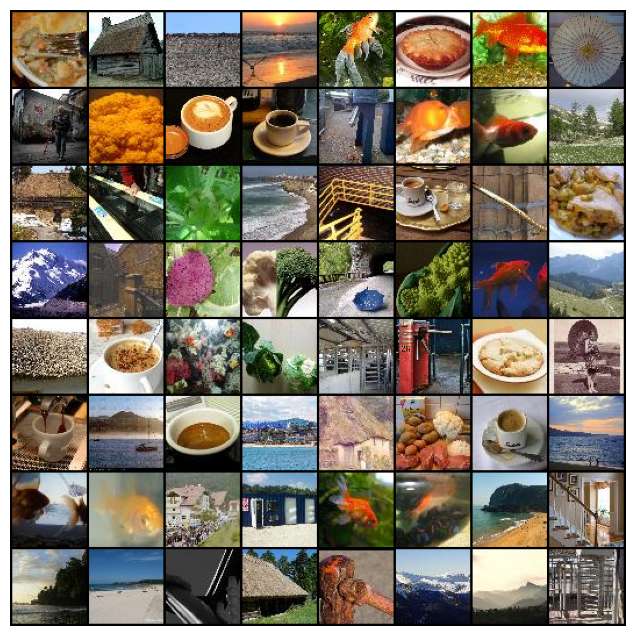

In [176]:
import numpy as np
import matplotlib.pyplot as plt

def show_images_grid(images):  # ← Pour GRID (batch)
    """Affiche batch d'images normalisées"""
    images = torchvision.utils.make_grid(images)  # [3, H*3, W*3]
    images = images
    images = torch.clamp(images, 0, 1)
    npimg = images.numpy().transpose((1, 2, 0))
    plt.figure(figsize=(8, 8))
    plt.imshow(npimg)
    plt.axis('off')
    plt.show()

# ✅ USAGE CORRECT
train_iter = iter(train_loader)
images, labels = next(train_iter)  # [B,3,64,64] + labels
show_images_grid(images)  # Affiche 64 images en grille 8x8

In [177]:
class_mapping = {
    0: "fish",
    1: "umbrella",
    2: "cup",
    3: "mountain",
    4: "beach",
    5: "thatched_roof",
    6: "merrygoround",
    7: "cabbage",
    8: "tart",
    9: "staircase"
}

np.set_printoptions(linewidth=120)
np.array([class_mapping[labels[j].item()] for j in range(64)]).reshape(8, 8)

array([['tart', 'thatched_roof', 'thatched_roof', 'beach', 'fish', 'tart', 'fish', 'umbrella'],
       ['umbrella', 'cabbage', 'cup', 'cup', 'merrygoround', 'fish', 'fish', 'mountain'],
       ['thatched_roof', 'staircase', 'cabbage', 'beach', 'staircase', 'cup', 'staircase', 'tart'],
       ['mountain', 'staircase', 'cabbage', 'cabbage', 'umbrella', 'cabbage', 'fish', 'mountain'],
       ['thatched_roof', 'cup', 'fish', 'cabbage', 'merrygoround', 'merrygoround', 'tart', 'umbrella'],
       ['cup', 'beach', 'cup', 'beach', 'thatched_roof', 'cabbage', 'cup', 'beach'],
       ['fish', 'fish', 'mountain', 'merrygoround', 'fish', 'fish', 'beach', 'staircase'],
       ['beach', 'beach', 'staircase', 'thatched_roof', 'staircase', 'mountain', 'mountain', 'merrygoround']],
      dtype='<U13')

## A ViT architecture using pytorch-lightning

Since we will use pytorch-lightning, our class needs to inherit from pl.LightningModule

In [ ]:
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import torchmetrics
from torchmetrics.classification import MulticlassConfusionMatrix


class VisionTransformer(pl.LightningModule):
    def __init__(self, num_classes=10):
        super(VisionTransformer, self).__init__()

        self.num_classes = num_classes
        self.confmat_log_path = "confusion_matrices.json"
        self.current_train_confmat = None

        self.patch_embed = nn.Conv2d(in_channels=3, out_channels=256, kernel_size=8, stride=8)

        self.cls_token = nn.Parameter(torch.randn(1, 1, 256))
        self.pos_embed = nn.Parameter(torch.randn(1, 65, 256))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            dropout=0.25,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6)

        self.fc1 = nn.Linear(in_features=256, out_features=600)
        self.drop = nn.Dropout(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=num_classes)

        self.accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=num_classes)

        self.train_confmat = MulticlassConfusionMatrix(num_classes=num_classes)
        self.val_confmat = MulticlassConfusionMatrix(num_classes=num_classes)

        self.train_loss = 0
        self.valid_loss = 0

    def encoder(self, x):
        B = x.shape[0]
        patches = self.patch_embed(x).flatten(2).transpose(1, 2)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, patches], dim=1)
        x = x + self.pos_embed
        out = self.transformer(x)
        return out[:, 0]

    def classifier(self, x):
        out = self.fc1(x)
        out = self.drop(F.relu(out))
        out = self.fc2(out)
        out = self.fc3(out)
        return out

    def forward(self, x):
        features = self.encoder(x)
        logits = self.classifier(features)
        return logits

    def _step_util(self, batch, batch_idx, step_type):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = torch.argmax(logits, dim=1)

        acc = self.accuracy(preds, y)

        self.log(f"{step_type}_loss", loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        self.log(f"{step_type}_acc", acc, on_step=False, on_epoch=True, prog_bar=True, logger=True)

        if step_type == "train":
            self.train_confmat.update(preds, y)
            self.train_loss += loss
        elif step_type == "valid":
            self.val_confmat.update(preds, y)
            self.valid_loss += loss

        return loss

    def training_step(self, batch, batch_idx):
        return self._step_util(batch, batch_idx, "train")

    def validation_step(self, batch, batch_idx):
        return self._step_util(batch, batch_idx, "valid")

    def _get_current_lr(self):
        return self.trainer.optimizers[0].param_groups[0]["lr"]

    def _append_epoch_to_json(self, epoch, train_loss, valid_loss, train_cm, val_cm):
        entry = {
            "epoch": int(epoch),
            "train_loss": round(self.train_loss.item(), 2),
            "valid_loss": round(self.valid_loss.item(), 2),
            "train": train_cm.cpu().tolist(),
            "val": val_cm.cpu().tolist()
        }

        if os.path.exists(self.confmat_log_path):
            with open(self.confmat_log_path, "r", encoding="utf-8") as f:
                try:
                    data = json.load(f)
                except json.JSONDecodeError:
                    data = []
        else:
            data = []

        data.append(entry)

        with open(self.confmat_log_path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4)

    def on_train_epoch_end(self):
        lr = self._get_current_lr()
        self.log("learning_rate", lr, on_step=False, on_epoch=True, prog_bar=True, logger=True)

        self.current_train_confmat = self.train_confmat.compute().detach().cpu()
        self.train_confmat.reset()

    def on_validation_epoch_end(self):
        val_cm = self.val_confmat.compute().detach().cpu()

        if self.current_train_confmat is not None:
            self._append_epoch_to_json(
                epoch=self.current_epoch,
                train_loss=self.train_loss,
                valid_loss=self.valid_loss,
                train_cm=self.current_train_confmat,
                val_cm=val_cm
            )

        self.val_confmat.reset()
        self.current_train_confmat = None
        self.train_loss = 0
        self.valid_loss = 0

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-5)

**Pro tip.** When coding and debugging your architecture, don't use print statements to check the sizes of input / output tensors for instance. Use pdb (python debbuger) by writing the line
```python
import pdb; pdb.set_trace()
```
at the place where you want to check stuff

In [179]:
net = VisionTransformer()
x = torch.randn(3, 3, 64, 64)
out = net(x)
out.size()

C:\Users\Yvan\AppData\Local\Temp\ipykernel_32148\498661007.py:33: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=6)


torch.Size([3, 10])

In [180]:
print(out)

tensor([[-0.7483,  0.2457, -0.6821,  0.3363, -0.3373,  0.3217, -0.4159, -0.0442,
          0.5851, -0.5906],
        [-0.5375,  0.2479, -0.4420,  0.3986, -0.3800,  0.1461, -0.3480,  0.0411,
          0.5128, -0.3694],
        [-0.5976,  0.0344, -0.8038,  0.6918, -0.4224,  0.2822,  0.2404, -0.2110,
          0.7239, -0.7397]], grad_fn=<AddmmBackward0>)


In [181]:
print(net)

VisionTransformer(
  (patch_embed): Conv2d(3, 256, kernel_size=(8, 8), stride=(8, 8))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-5): 6 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.25, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.25, inplace=False)
        (dropout2): Dropout(p=0.25, inplace=False)
      )
    )
  )
  (fc1): Linear(in_features=256, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_

**Pro tip.** Pytorch lighting proposes many very convenient flags to try and debug before testing. For instance, `fast_dev_run` runs some training and validation steps in order to check that everyting works.

## Train for some epochs


In [182]:
MAX_EPOCHS = 100

trainer = pl.Trainer(max_epochs=MAX_EPOCHS,
                     accelerator="auto",
                     devices="auto")

trainer.fit(net, train_dataloaders=train_loader, val_dataloaders=valid_loader)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type                      | Params | Mode  | FLOPs
----------------------------------------------------------------------------
0 | patch_embed   | Conv2d                    | 49.4 K | train | 0    
1 | transformer   | TransformerEncoder        | 3.2 M  | train | 0    
2 | fc1           | Linear                    | 154 K  | train | 0    
3 | drop          | Dropout                   | 0      | train | 0    
4 | fc2   

Epoch 99: 100%|██████████| 55/55 [00:03<00:00, 17.68it/s, v_num=4, valid_loss=1.440, valid_acc=0.476, train_loss=1.470, train_acc=0.474, learning_rate=1e-5]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 55/55 [00:03<00:00, 16.91it/s, v_num=4, valid_loss=1.440, valid_acc=0.476, train_loss=1.470, train_acc=0.474, learning_rate=1e-5]


In [183]:
trainer.save_checkpoint("ViT_modele.ckpt")

`weights_only` was not set, defaulting to `False`.
